# Extracting features and embeddings of VocalSet VTC Dataset



## 1. Setup

In [78]:
import types, importlib, sys
imp = types.ModuleType("imp")
imp.reload = importlib.reload
sys.modules["imp"] = imp
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
from vocalSet_data_config import vocalset_dataset_config
from vocalset_extraction_config import vocalset_extraction
from scripts.validate_config import validate_configs

# Create dataset instance by calling the function
vocalset_dataset = vocalset_dataset_config()

print(f"Dataset: {vocalset_dataset.name}")
print(f"Root directory: {vocalset_dataset.root_dir}")
print(f"Levels: {vocalset_dataset.level_names}")

# View extraction configuration
print(f"\nExtractors: {vocalset_extraction.extractors}")
print(f"Output directory: {vocalset_extraction.output_dir}")
print(f"Window lengths: {vocalset_extraction.window_lengths}")

# Validate configurations
try:
    validate_configs(vocalset_dataset, vocalset_extraction)
    print("\n✓ Configurations are valid!")
except ValueError as e:
    print(f"\n✗ Configuration error: {e}")

Dataset: vocalset_dataset
Root directory: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/FULL
Levels: ['singer', 'exercise_type', 'vocal_technique']

Extractors: ['mfcc', 'opensmile', 'vggish', 'clap', 'whisper']
Output directory: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/
Window lengths: [3.0]

✓ Configurations are valid!


## 2. Run Extractions

In [80]:
import logging
from scripts.run_extraction import run_extraction
from pathlib import Path

# Run extraction (this may take a while depending on dataset size)
log_file = "/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log_3sec.jsonl"

# Pass file paths to run_extraction (not the config objects)
run_extraction(
    dataset_config_path="vocalSet_data_config.py",
    extraction_config_path="vocalset_extraction_config.py",
    log_file=log_file,
    console_output=False, # aim to reduce memory use of VSCode so the session doesnt crash
    overwrite=True
)

print(f"✓ Extraction complete! Logs saved to {log_file}")

[INFO] 3613 total files | 0 already processed | 3613 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_mfcc-13d_3.0s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_mfcc-13d_3.0s.parquet


[mfcc-13d] vocalset_dataset: 100%|██████████| 3613/3613 [04:14<00:00, 14.21file/s, frames=53, file=m9_scales_vocal_fry_u.wav, extracted=4]        


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_mfcc-13d_3.0s.parquet
[INFO] 10546 total frame embeddings from 3613 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_mfcc-13d_3.0s.json
[INFO] Cleaned up HDF5 and checkpoint files.
[INFO] OpenSMILE compare-2016: 6373 features
[INFO] 3613 total files | 0 already processed | 3613 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_opensmile-compare-2016_3.0s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_opensmile-compare-2016_3.0s.parquet


[opensmile-compare-2016] vocalset_dataset: 100%|██████████| 3613/3613 [05:48<00:00, 10.35file/s, frames=53, file=m9_scales_vocal_fry_u.wav, extracted=4]        


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_opensmile-compare-2016_3.0s.parquet
[INFO] 10546 total frame embeddings from 3613 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_opensmile-compare-2016_3.0s.json
[INFO] Cleaned up HDF5 and checkpoint files.


...

[INFO] Loading Whisper encoder (openai/whisper-base) on cuda
[INFO] 3613 total files | 0 already processed | 3613 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_whisper_whisper-base_3.0s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_whisper_whisper-base_3.0s.parquet


[whisper_whisper-base] vocalset_dataset: 100%|██████████| 3613/3613 [02:04<00:00, 28.97file/s, frames=53, file=m9_scales_vocal_fry_u.wav, extracted=4]        


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_whisper_whisper-base_3.0s.parquet
[INFO] 10546 total frame embeddings from 3613 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/3sec/vocalset_dataset_whisper_whisper-base_3.0s.json


INFO:audio_extraction:Extraction complete: whisper @ 3.0s | 3613 files, 10546 frames | 0 errors, 0 warnings | 125.0s
DEBUG:audio_extraction:Resource checkpoint | CPU: 3.6% | RAM: 22.5GB used, 40.1GB available | GPU: 0.3GB used, 15.2GB available
INFO:audio_extraction:Extraction pipeline complete | 18065 files, 52730 frames | 0 errors | 1731.3s


[INFO] Cleaned up HDF5 and checkpoint files.
✓ Extraction complete! Logs saved to /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log_3sec.jsonl


In [5]:

# Check the logs to see what happened during extraction
import json
from pathlib import Path

log_file = Path("/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log.jsonl")

print(f"Log file: {log_file}")
print(f"File exists: {log_file.exists()}")
print(f"File size: {log_file.stat().st_size if log_file.exists() else 'N/A'} bytes")

if log_file.exists():
    print("\n--- Last 20 log entries ---")
    with open(log_file) as f:
        lines = f.readlines()
        for line in lines[-20:]:
            entry = json.loads(line.strip())
            stage = entry.get("stage", "?")
            level = entry.get("level", "?")
            message = entry.get("message", "")[:80]  # First 80 chars
            print(f"[{level:5s}] {stage:25s} | {message}")


Log file: /home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/vocalset_extraction_run_log.jsonl
File exists: True
File size: 23412 bytes

--- Last 20 log entries ---
[INFO ] initialization            | Extraction pipeline starting
[INFO ] extraction_start          | Starting extraction: clap @ 3.0s for vocalset_dataset
[INFO ] initialization            | Resolved batch_size: 100 files
[INFO ] initialization            | Extraction pipeline starting
[INFO ] extraction_start          | Starting extraction: clap @ 3.0s for vocalset_dataset
[INFO ] initialization            | Resolved batch_size: 100 files
[INFO ] initialization            | Extraction pipeline starting
[INFO ] extraction_start          | Starting extraction: clap @ 3.0s for vocalset_dataset
[INFO ] extraction_complete       | Extraction complete: clap @ 3.0s | 3460 files, 10148 frames | 0 errors, 0 warnin
[DEBUG] resource_checkpoint       | Resource checkpoint | CPU: 9.4% | RAM: 23.5GB used, 39.1GB avail

In [5]:

# First, check what output files already exist
from pathlib import Path
output_dir = Path("/home/suvihaara/Documents/PhD/DATA/VocalSet/VocalSet_fixed/embeddings/")

print("Existing parquet files:")
for f in sorted(output_dir.glob("*.parquet")):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  - {f.name:60s} ({size_mb:.1f} MB)")

print("\nExisting checkpoint files:")
checkpoints = list(output_dir.glob("*.checkpoint.jsonl"))
if checkpoints:
    for cp in sorted(checkpoints):
        print(f"  - {cp.name}")
else:
    print("  (none - these get cleaned up after successful extraction)")

print("\nExisting HDF5 files:")
h5_files = list(output_dir.glob("*.h5"))
if h5_files:
    for h5 in sorted(h5_files):
        print(f"  - {h5.name}")
else:
    print("  (none - these get cleaned up after successful extraction)")


Existing parquet files:
  - vocalset_dataset_clap-2023_0.5s.parquet                      (297.7 MB)
  - vocalset_dataset_clap-2023_3.0s.parquet                      (39.8 MB)
  - vocalset_dataset_mfcc-13d_0.5s.parquet                       (4.1 MB)
  - vocalset_dataset_mfcc-13d_3.0s.parquet                       (0.7 MB)
  - vocalset_dataset_opensmile-compare-2016_0.5s.parquet         (1710.4 MB)
  - vocalset_dataset_opensmile-compare-2016_3.0s.parquet         (252.7 MB)
  - vocalset_dataset_vggish_0.5s.parquet                         (37.5 MB)
  - vocalset_dataset_vggish_3.0s.parquet                         (5.3 MB)
  - vocalset_dataset_whisper_whisper-base_0.5s.parquet           (149.1 MB)
  - vocalset_dataset_whisper_whisper-base_3.0s.parquet           (20.8 MB)

Existing checkpoint files:
  (none - these get cleaned up after successful extraction)

Existing HDF5 files:
  (none - these get cleaned up after successful extraction)


## 3. Explore results

In [6]:
from scripts.utils import load_parquet  
# Load extraction results

output_dir = Path(vocalset_extraction.output_dir)

# List all output files
output_files = list(output_dir.glob("*.parquet"))
print("Generated output files:")
for f in output_files:
    print(f"  - {f.name}")

Generated output files:
  - vocalset_dataset_mfcc-13d_3.0s.parquet
  - vocalset_dataset_clap-2023_3.0s.parquet
  - vocalset_dataset_whisper_whisper-base_0.5s.parquet
  - vocalset_dataset_vggish_3.0s.parquet
  - vocalset_dataset_whisper_whisper-base_3.0s.parquet
  - vocalset_dataset_mfcc-13d_0.5s.parquet
  - vocalset_dataset_opensmile-compare-2016_3.0s.parquet
  - vocalset_dataset_clap-2023_0.5s.parquet
  - vocalset_dataset_opensmile-compare-2016_0.5s.parquet
  - vocalset_dataset_vggish_0.5s.parquet


In [13]:
import os 

df_opensmile = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_opensmile-compare-2016_3.0s.parquet")
)

print(f"Data shape: {df_opensmile.shape}")
print(f"Columns: {list(df_opensmile.columns)}")
print(f"\nFirst few rows:")
df_opensmile.head()

Data shape: (10546, 10)
Columns: ['exercise_type', 'extractor', 'filename', 'filepath', 'frame_index', 'singer', 'vocal_technique', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,exercise_type,extractor,filename,filepath,frame_index,singer,vocal_technique,embedding,embedding_dtype,embedding_shape
0,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[2.1086946, 0.97269624, 0.0, 0.6850486, 0.8989...",<f4,[6373]
1,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[1.5428679, 0.3208191, 0.9897611, 0.8161966, 1...",<f4,[6373]
2,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[1.6066055, 0.97952217, 0.0, 0.5867397, 0.9134...",<f4,[6373]
3,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[0.86089426, 0.25938568, 0.6450512, 0.83925277...",<f4,[6373]
4,arpeggios,opensmile-compare-2016,f1_arpeggios_belt_c_i,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[1.7399231, 0.97952217, 0.0, 0.31953323, 0.554...",<f4,[6373]


In [14]:
df_vgg = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_vggish_3.0s.parquet")
)

print(f"Data shape: {df_vgg.shape}")
print(f"Columns: {list(df_vgg.columns)}")
print(f"\nFirst few rows:")
df_vgg.head()

Data shape: (10546, 10)
Columns: ['exercise_type', 'extractor', 'filename', 'filepath', 'frame_index', 'singer', 'vocal_technique', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,exercise_type,extractor,filename,filepath,frame_index,singer,vocal_technique,embedding,embedding_dtype,embedding_shape
0,arpeggios,vggish,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-0.6765644, 0.025506744, 0.31746656, 0.029211...",<f4,[128]
1,arpeggios,vggish,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[-0.5535863, -0.0055851243, 0.5195823, -0.2176...",<f4,[128]
2,arpeggios,vggish,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-0.07326427, 0.053907428, 0.31804642, 0.07114...",<f4,[128]
3,arpeggios,vggish,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[-0.26125073, 0.027375689, 0.35385522, 0.01045...",<f4,[128]
4,arpeggios,vggish,f1_arpeggios_belt_c_i,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-0.26933783, -0.027348975, 0.24391548, 0.0705...",<f4,[128]


In [15]:
df_clap = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_clap-2023_3.0s.parquet")
)

print(f"Data shape: {df_clap.shape}")
print(f"Columns: {list(df_clap.columns)}")
print(f"\nFirst few rows:")
df_clap.head()

Data shape: (10148, 10)
Columns: ['exercise_type', 'extractor', 'filename', 'filepath', 'frame_index', 'singer', 'vocal_technique', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,exercise_type,extractor,filename,filepath,frame_index,singer,vocal_technique,embedding,embedding_dtype,embedding_shape
0,scales,clap-2023,f1_scales_f_slow_forte_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,slow_forte,"[0.27486065, 0.45118785, 0.56402445, 1.7583125...",<f4,[1024]
1,scales,clap-2023,f1_scales_f_slow_forte_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,slow_forte,"[0.9673973, 0.5879903, 0.93139064, 2.1932523, ...",<f4,[1024]
2,scales,clap-2023,f1_scales_f_slow_forte_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,2,female1,slow_forte,"[0.881724, -0.2521697, 0.45413852, 2.2416394, ...",<f4,[1024]
3,scales,clap-2023,f1_scales_f_slow_forte_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,3,female1,slow_forte,"[0.60533756, -0.14582421, 0.040658455, 1.93323...",<f4,[1024]
4,scales,clap-2023,f1_scales_f_slow_forte_i,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,slow_forte,"[0.5213859, 0.6680085, 0.6748907, 1.9770023, 1...",<f4,[1024]


In [16]:
df_whisper = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_whisper_whisper-base_3.0s.parquet")
)

print(f"Data shape: {df_whisper.shape}")
print(f"Columns: {list(df_whisper.columns)}")
print(f"\nFirst few rows:")
df_whisper.head()

Data shape: (10546, 10)
Columns: ['exercise_type', 'extractor', 'filename', 'filepath', 'frame_index', 'singer', 'vocal_technique', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,exercise_type,extractor,filename,filepath,frame_index,singer,vocal_technique,embedding,embedding_dtype,embedding_shape
0,arpeggios,whisper_whisper-base,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-0.01772064, -0.3895843, 0.13550071, -1.05723...",<f4,[512]
1,arpeggios,whisper_whisper-base,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[-0.017140422, -0.46592912, 0.22362714, -0.990...",<f4,[512]
2,arpeggios,whisper_whisper-base,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-0.086606406, -0.60057575, 0.1167342, -1.0132...",<f4,[512]
3,arpeggios,whisper_whisper-base,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[-0.07753566, -0.66186184, 0.19897744, -0.9741...",<f4,[512]
4,arpeggios,whisper_whisper-base,f1_arpeggios_belt_c_i,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-0.013903398, -0.50197566, 0.14436503, -0.902...",<f4,[512]


In [17]:
import os 

df_mfcc = load_parquet(
    os.path.join(output_dir, "vocalset_dataset_mfcc-13d_3.0s.parquet")
)

print(f"Data shape: {df_mfcc.shape}")
print(f"Columns: {list(df_mfcc.columns)}")
print(f"\nFirst few rows:")
df_mfcc.head()

Data shape: (10546, 10)
Columns: ['exercise_type', 'extractor', 'filename', 'filepath', 'frame_index', 'singer', 'vocal_technique', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,exercise_type,extractor,filename,filepath,frame_index,singer,vocal_technique,embedding,embedding_dtype,embedding_shape
0,arpeggios,mfcc-13d,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-298.82925, -0.88876903, -89.66744, -28.93947...",<f4,[13]
1,arpeggios,mfcc-13d,f1_arpeggios_belt_c_a,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[-276.69284, -28.10886, -86.84994, -51.135456,...",<f4,[13]
2,arpeggios,mfcc-13d,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-366.95798, 2.6056712, -66.77095, 59.969368, ...",<f4,[13]
3,arpeggios,mfcc-13d,f1_arpeggios_belt_c_e,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,1,female1,belt,"[-359.73877, -15.736272, -67.094345, 45.64235,...",<f4,[13]
4,arpeggios,mfcc-13d,f1_arpeggios_belt_c_i,/home/suvihaara/Documents/PhD/DATA/VocalSet/Vo...,0,female1,belt,"[-425.58505, -29.897825, -8.22196, 88.78101, -...",<f4,[13]


In [29]:
from scripts.feature_visualisation import prepare_and_plot_lda

female_singers = [
    "female1",
    "female2",
    "female3",
    "female4",
    "female6",
    "female5",
    "female7",
    "female8",
    "female9",
]

male_singers = [
    "male1",
    "male2",
    "male3",
    "male4",
    "male5",
    "male6",
    "male7",
    "male8",
    "male9",
    "male10",
    "male11",
]

vocalset_10way = [
    "vibrato",
    "straight",
    "trill",
    "trillo",
    "belt",
    "breathy",
    "inhaled",
    "spoken",
    "vocal_fry",
    "lip_trill",
]

pmt = ["vibrato", "straight", "trill", "trillo"]
tmt = ["belt", "breathy", "inhaled", "spoken", "vocal_fry"]

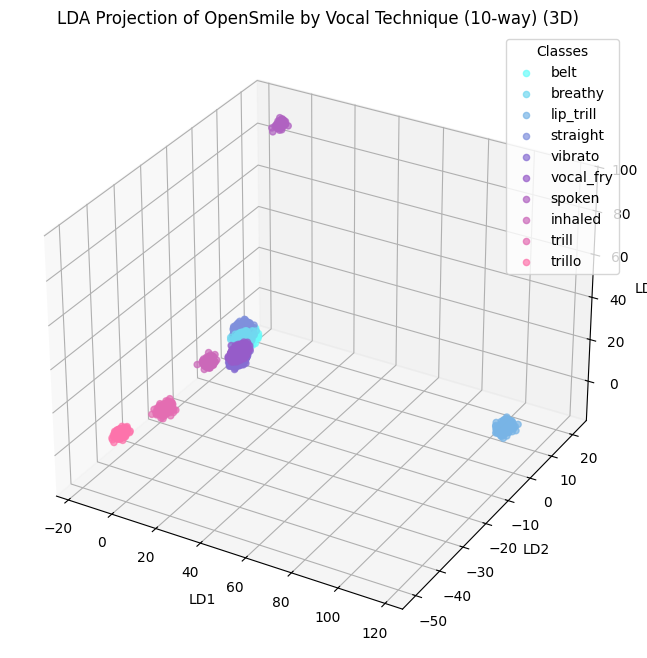

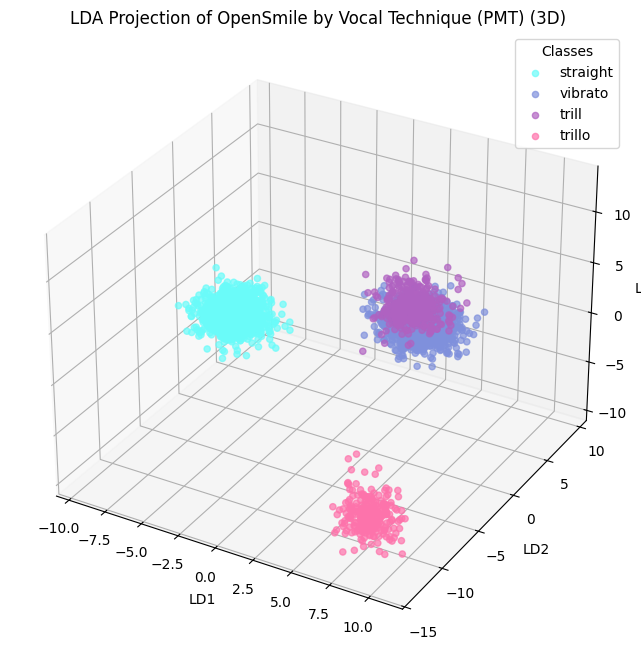

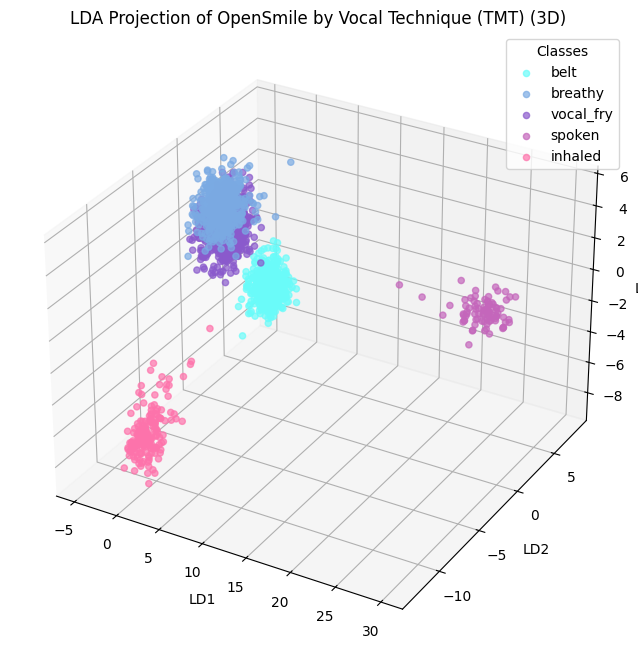

In [68]:
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (10-way)",
    filters={"vocal_technique": vocalset_10way},
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (PMT)",
    filters={"vocal_technique": pmt },
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (TMT)",
    filters={"vocal_technique": tmt },
    palette="musa_palette",
)

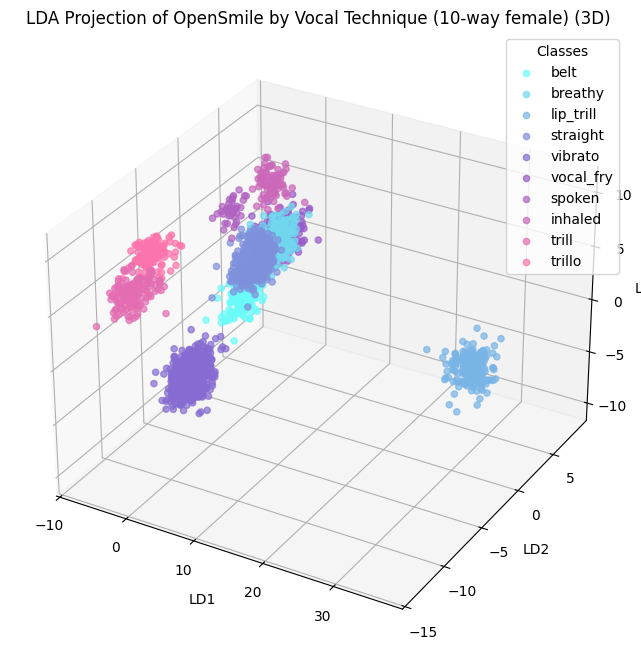

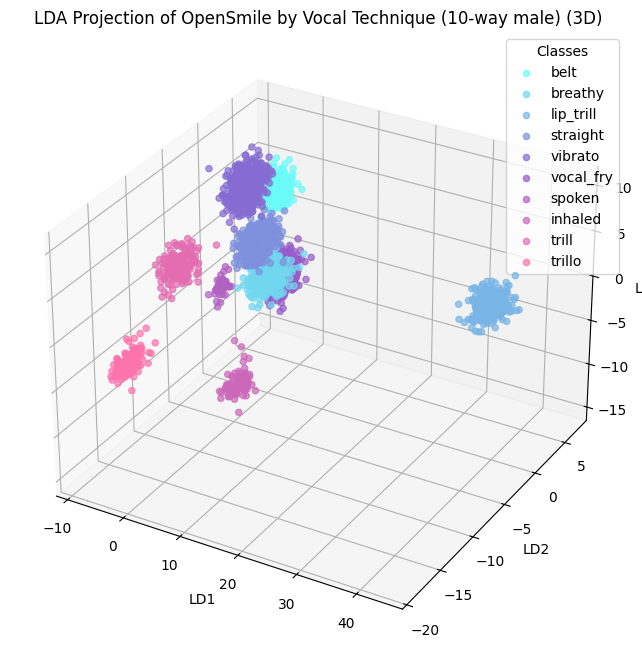

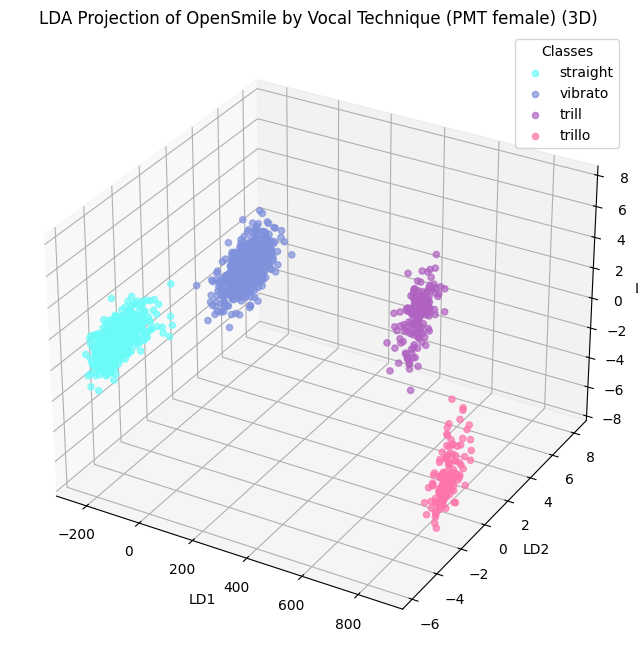

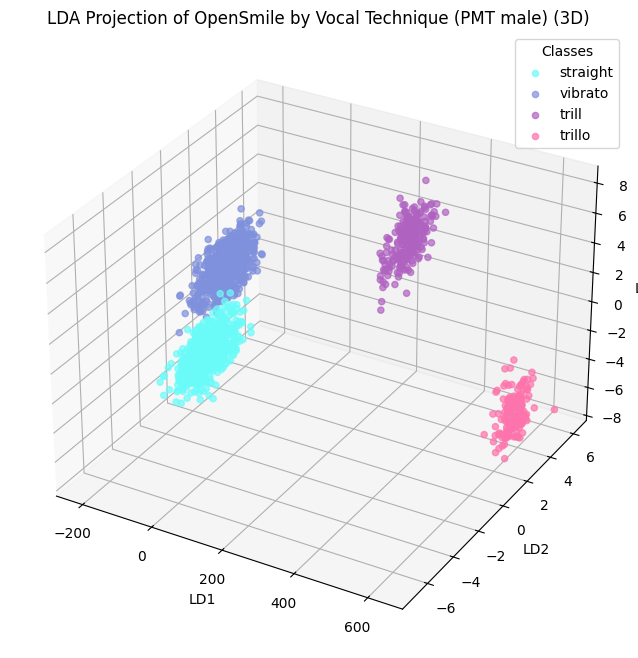

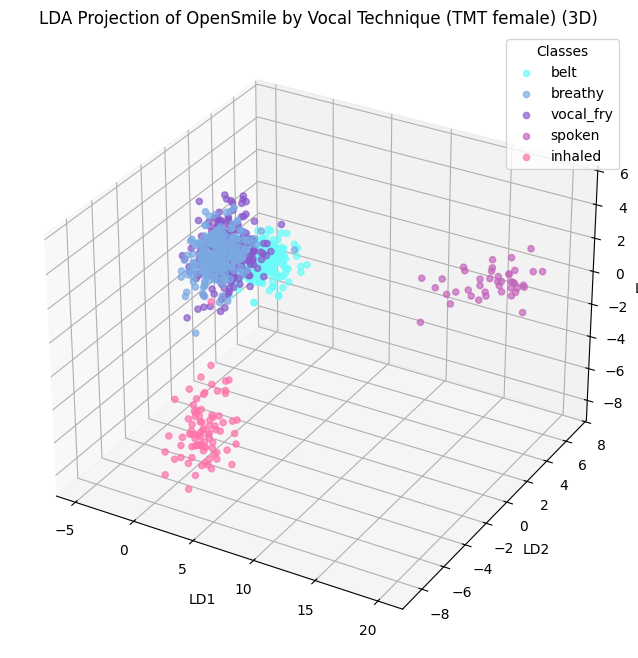

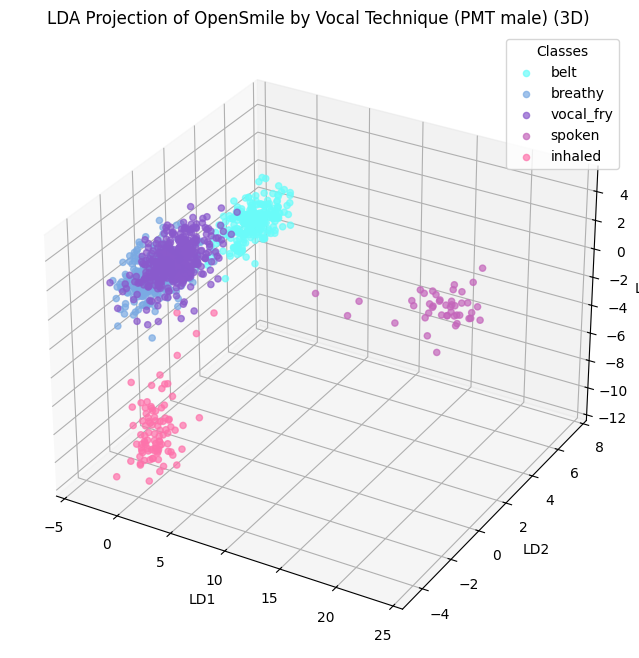

In [69]:
# female only
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (10-way female)",
    filters={
        "vocal_technique": vocalset_10way,
        "singer": female_singers
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (10-way male)",
    filters={
        "vocal_technique": vocalset_10way,
        "singer": male_singers
    },
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (PMT female)",
    filters={
        "vocal_technique": pmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": pmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (TMT female)",
    filters={
        "vocal_technique": tmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_opensmile,
    class_col="vocal_technique",
    mode="3d",
    data_type="OpenSmile by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": tmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

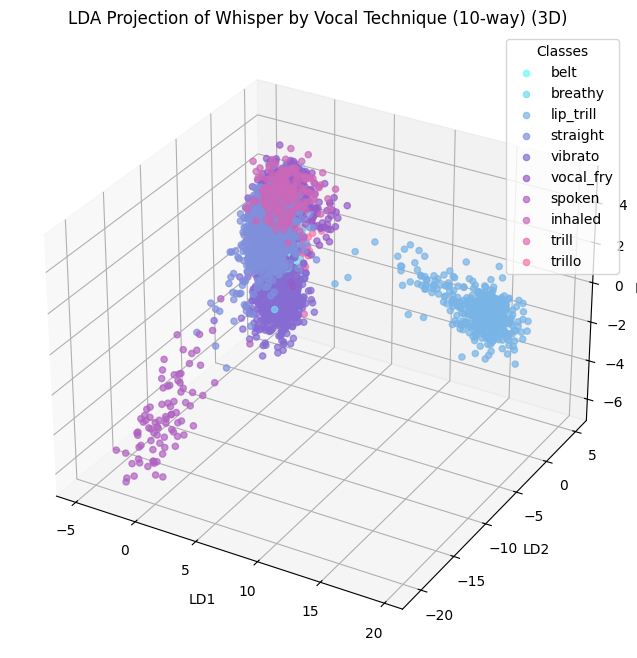

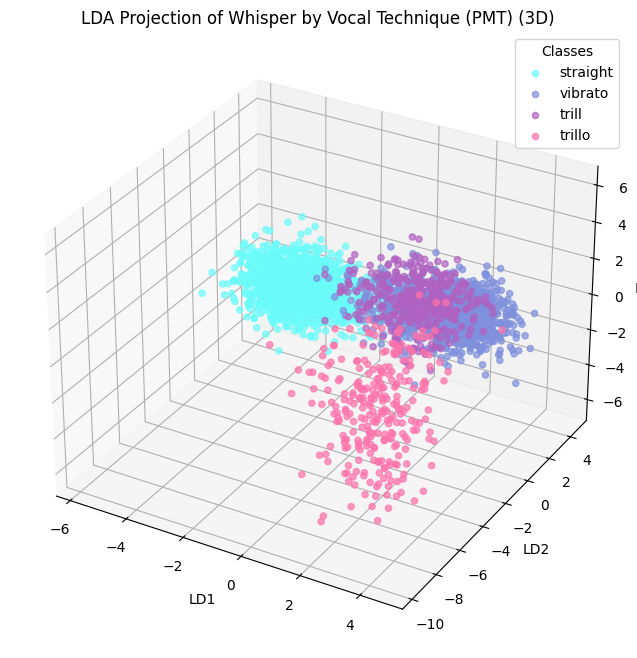

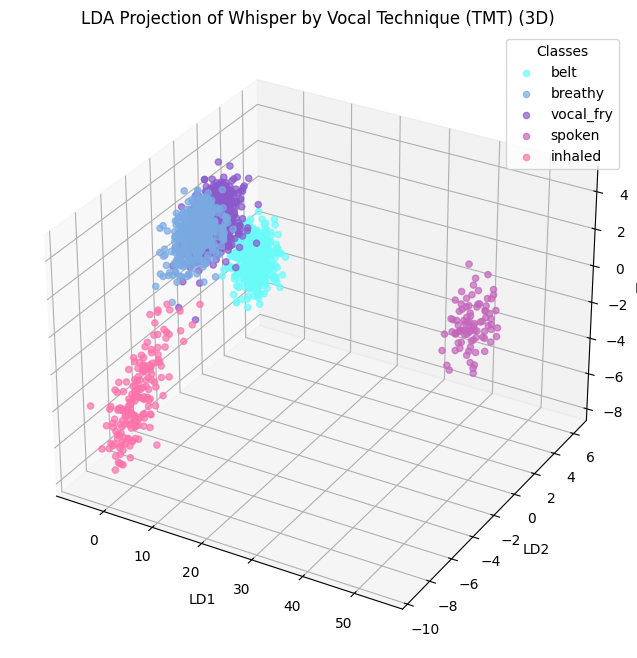

In [70]:
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (10-way)",
    filters={"vocal_technique": vocalset_10way},
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (PMT)",
    filters={"vocal_technique": pmt},
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (TMT)",
    filters={"vocal_technique": tmt},
    palette="musa_palette",
)

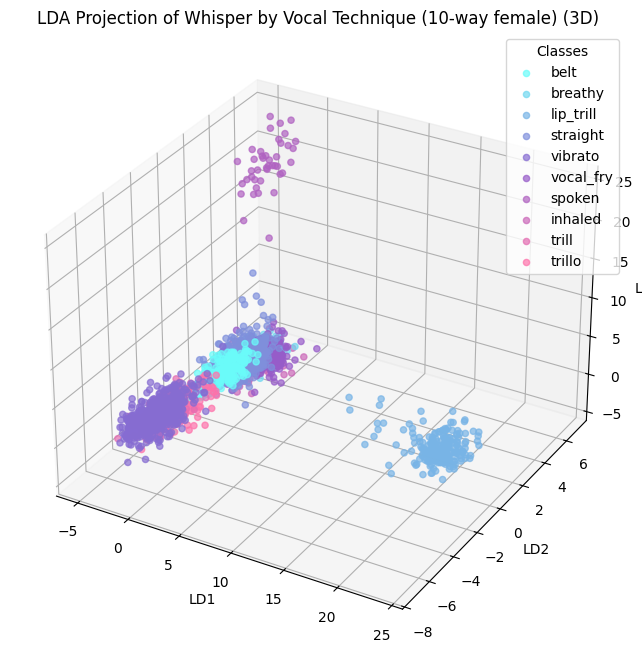

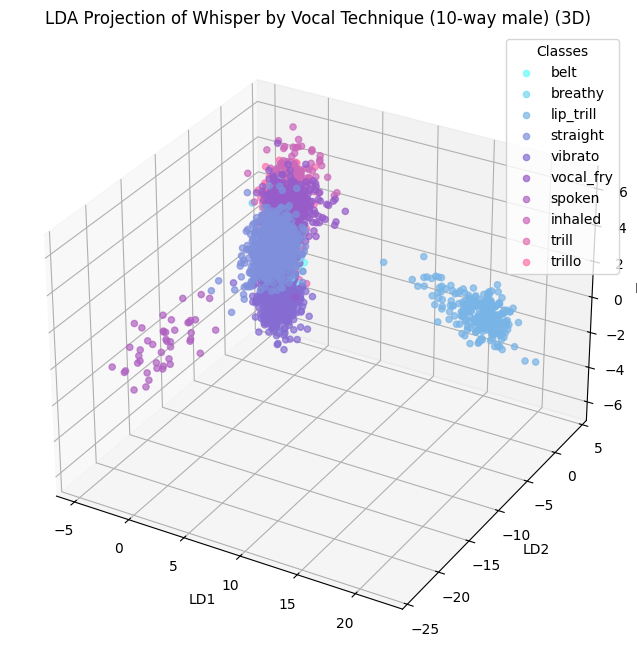

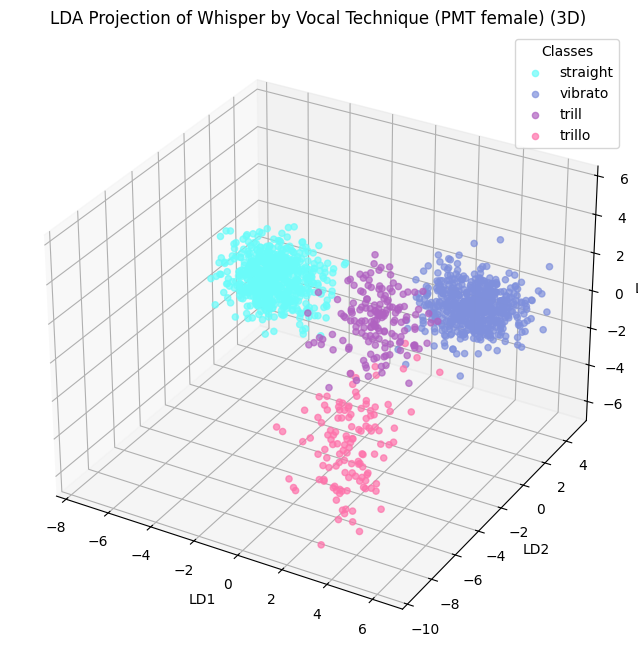

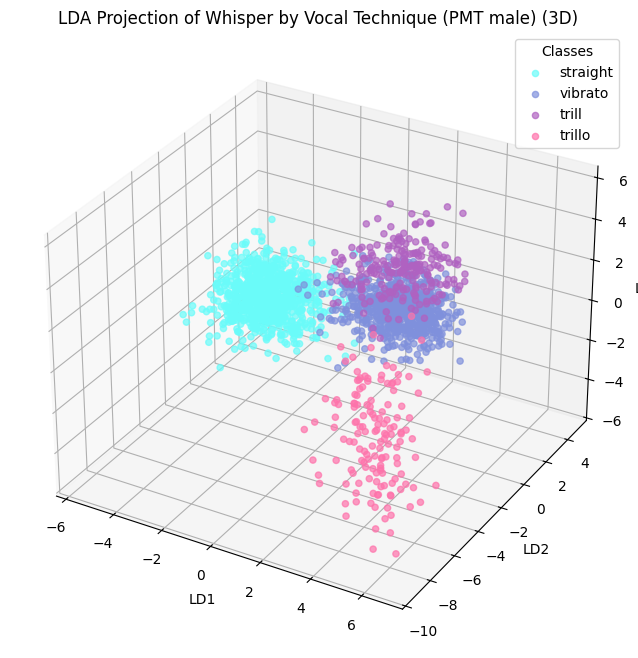

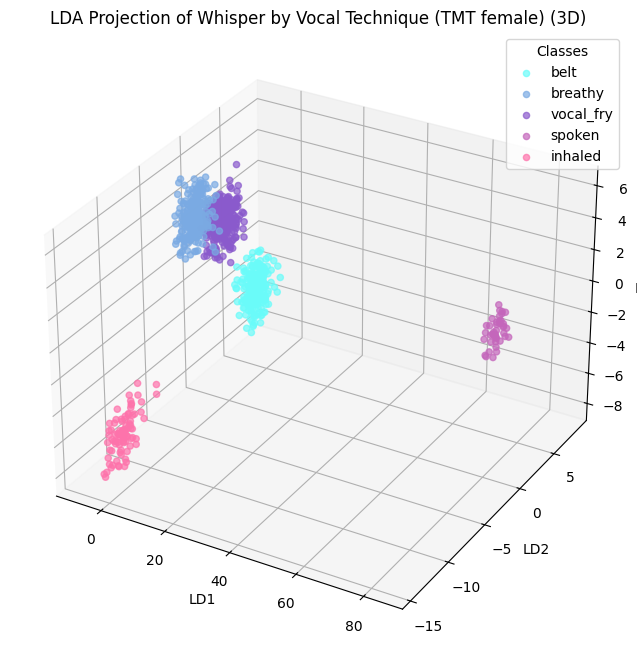

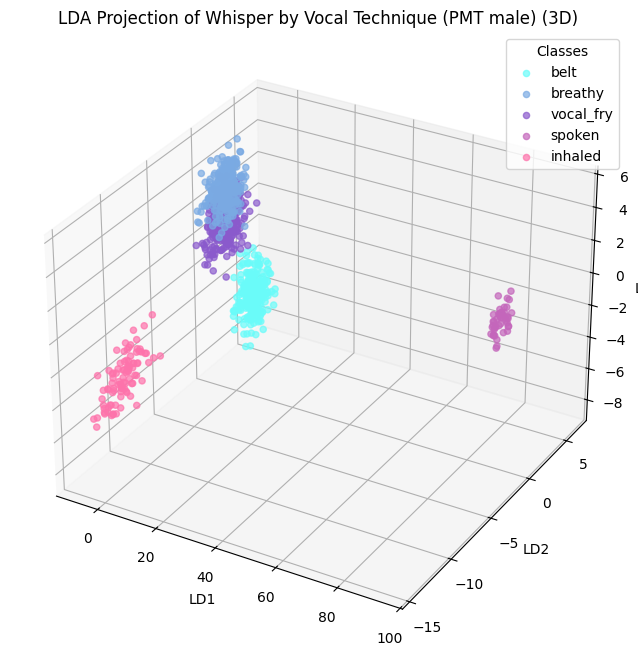

In [71]:
# female only
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (10-way female)",
    filters={"vocal_technique": vocalset_10way, "singer": female_singers},
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (10-way male)",
    filters={"vocal_technique": vocalset_10way, "singer": male_singers},
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (PMT female)",
    filters={
        "vocal_technique": pmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": pmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (TMT female)",
    filters={
        "vocal_technique": tmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_whisper,
    class_col="vocal_technique",
    mode="3d",
    data_type="Whisper by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": tmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

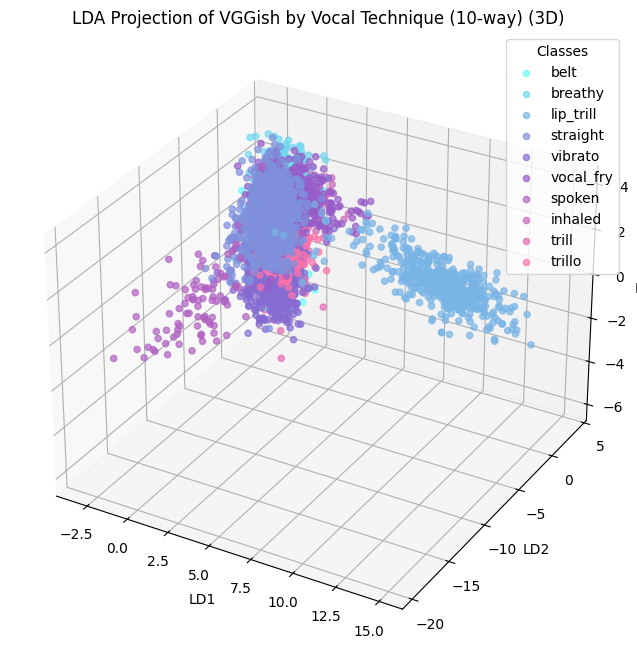

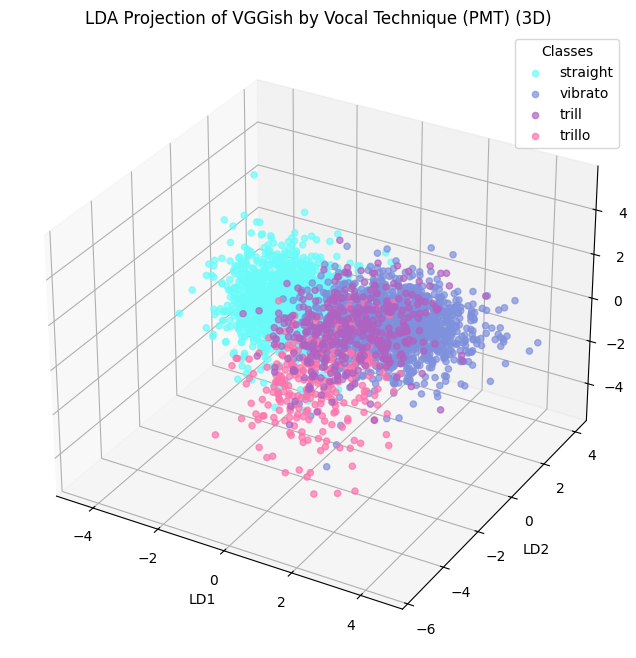

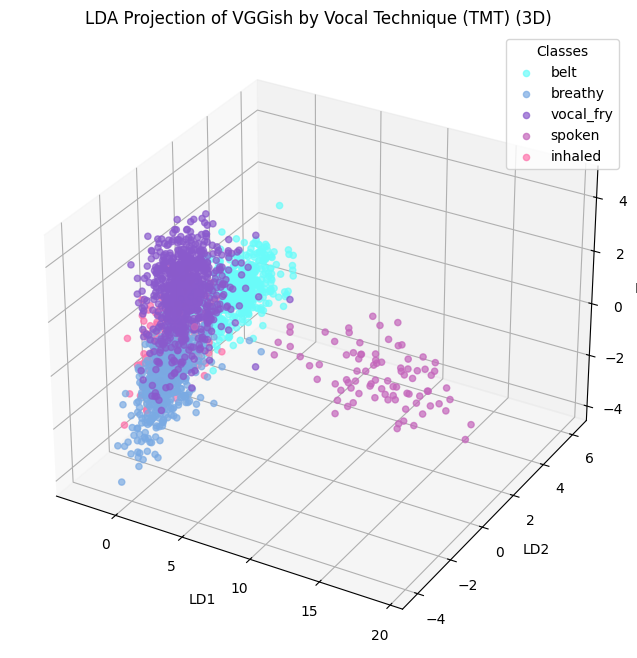

In [72]:
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (10-way)",
    filters={
        "vocal_technique": vocalset_10way
    },
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (PMT)",
    filters={"vocal_technique": pmt},
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (TMT)",
    filters={"vocal_technique": tmt},
    palette="musa_palette",
)

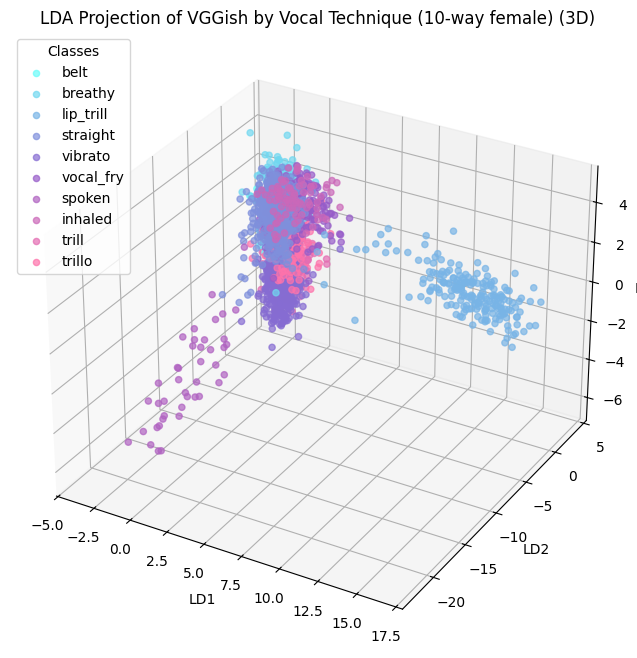

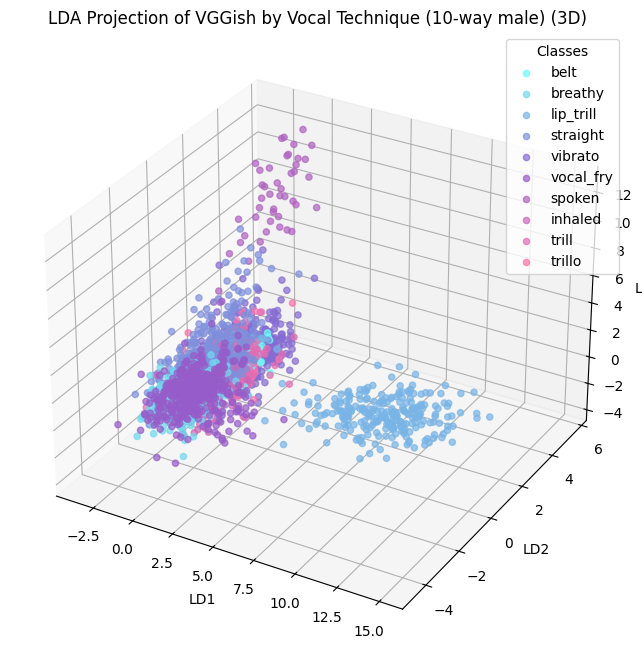

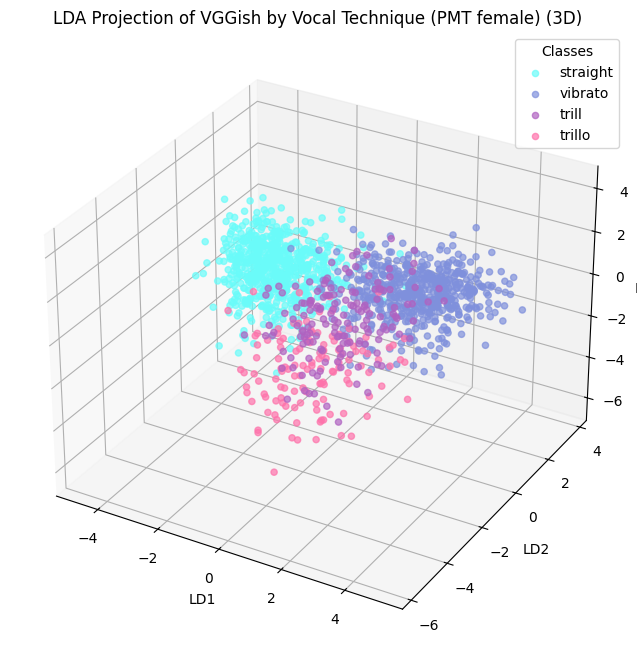

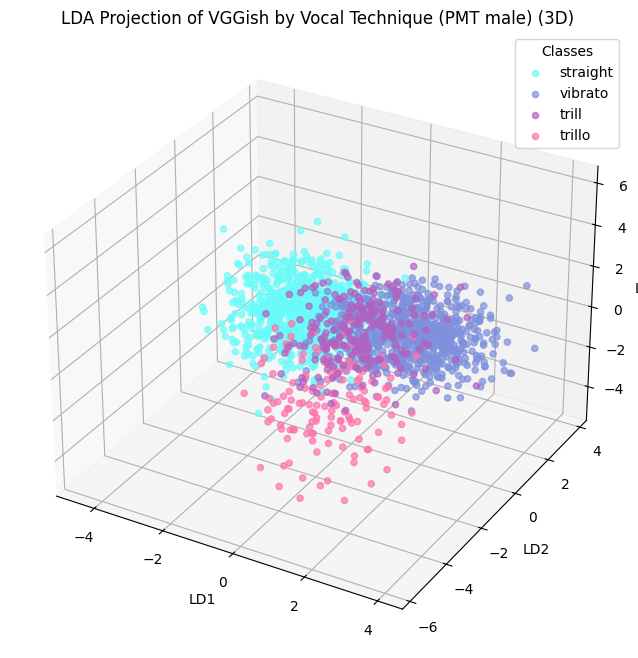

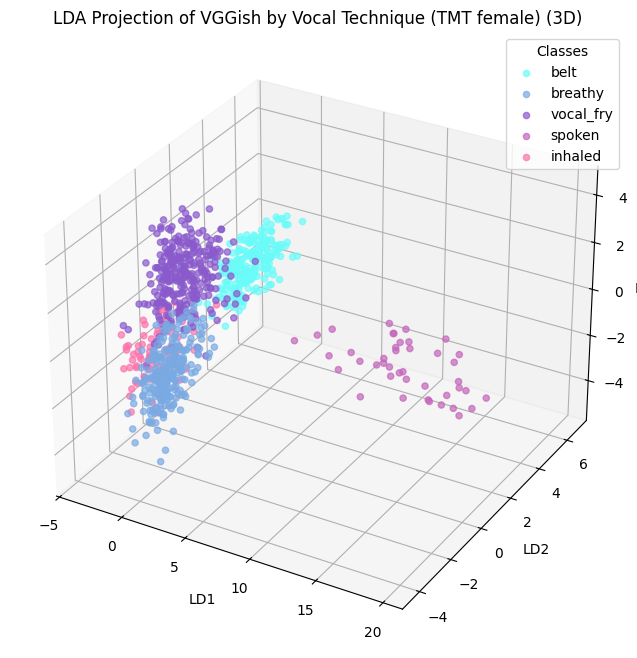

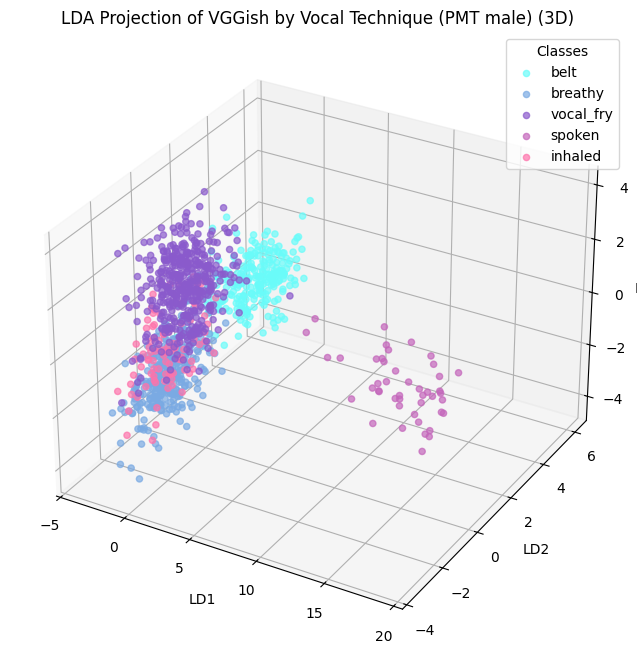

In [73]:
# female only
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (10-way female)",
    filters={"vocal_technique": vocalset_10way, "singer": female_singers},
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (10-way male)",
    filters={"vocal_technique": vocalset_10way, "singer": male_singers},
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (PMT female)",
    filters={
        "vocal_technique": pmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": pmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (TMT female)",
    filters={
        "vocal_technique": tmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_vgg,
    class_col="vocal_technique",
    mode="3d",
    data_type="VGGish by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": tmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

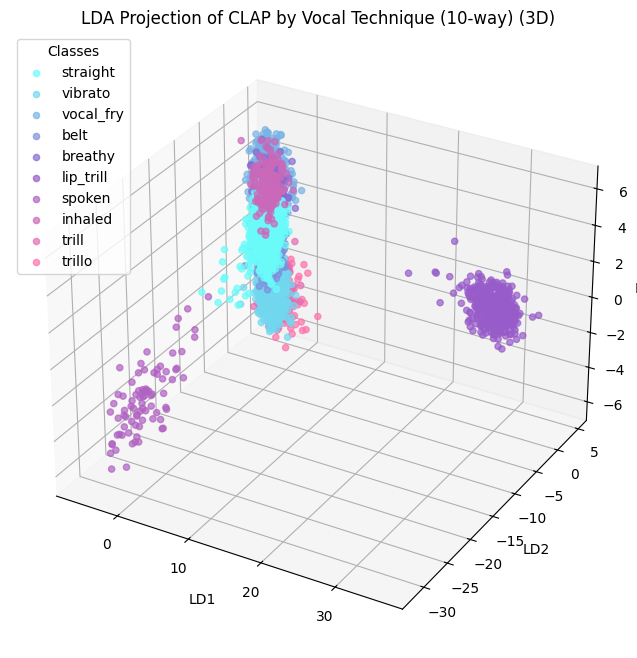

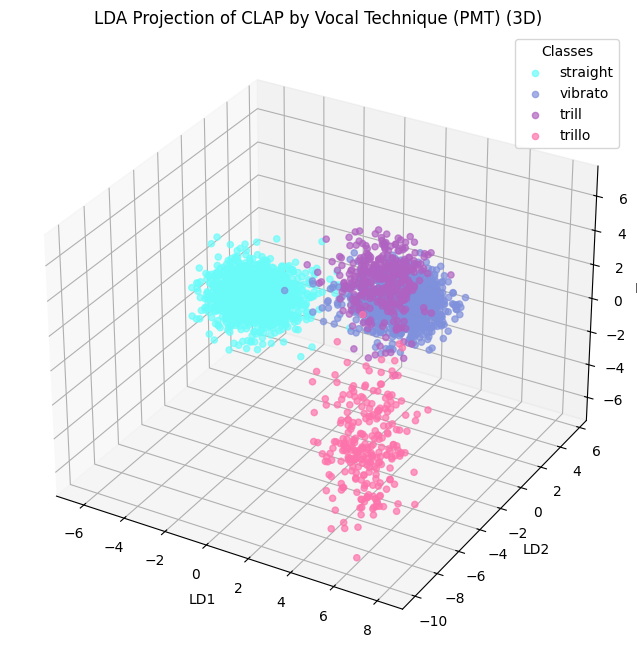

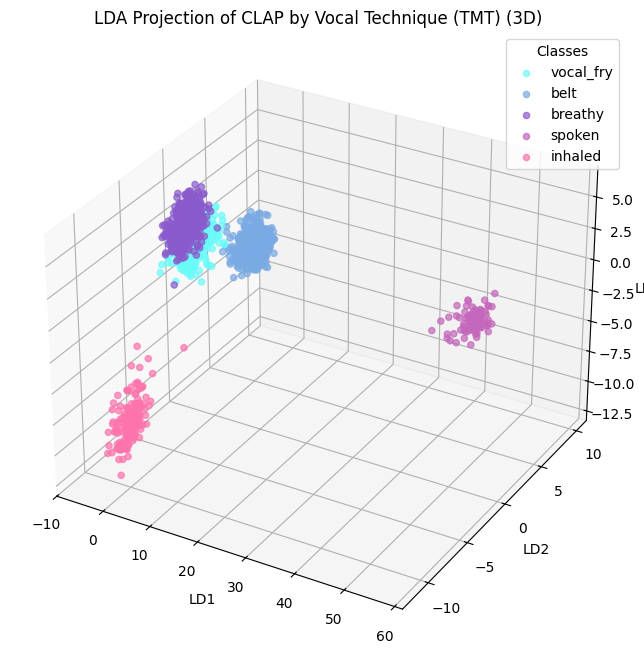

In [74]:
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (10-way)",
    filters={
        "vocal_technique": vocalset_10way
    },
    palette= "musa_palette"
)

prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (PMT)",
    filters={"vocal_technique": pmt},
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (TMT)",
    filters={"vocal_technique": tmt},
    palette="musa_palette",
)

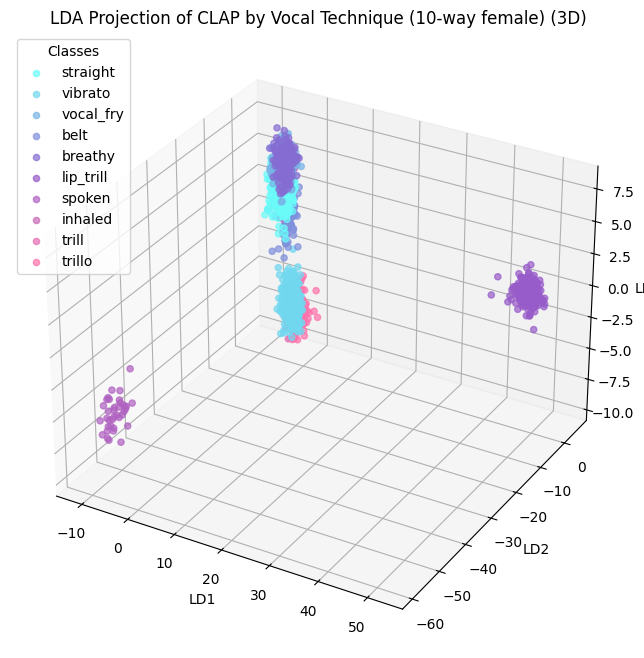

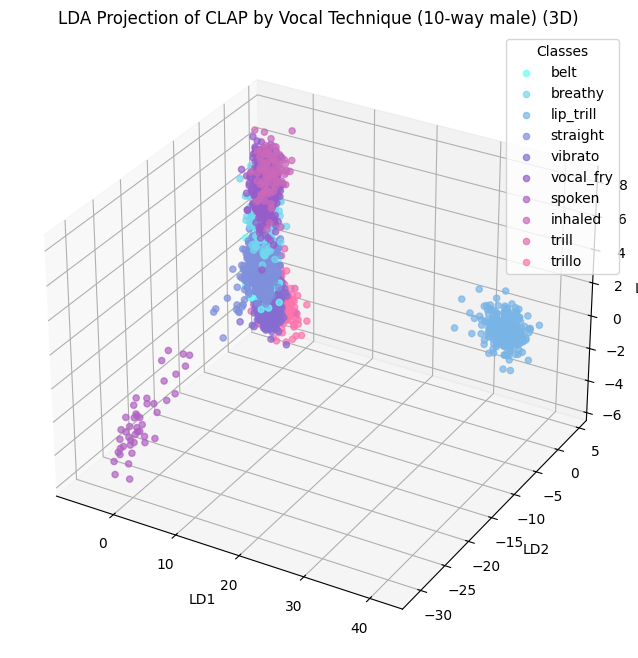

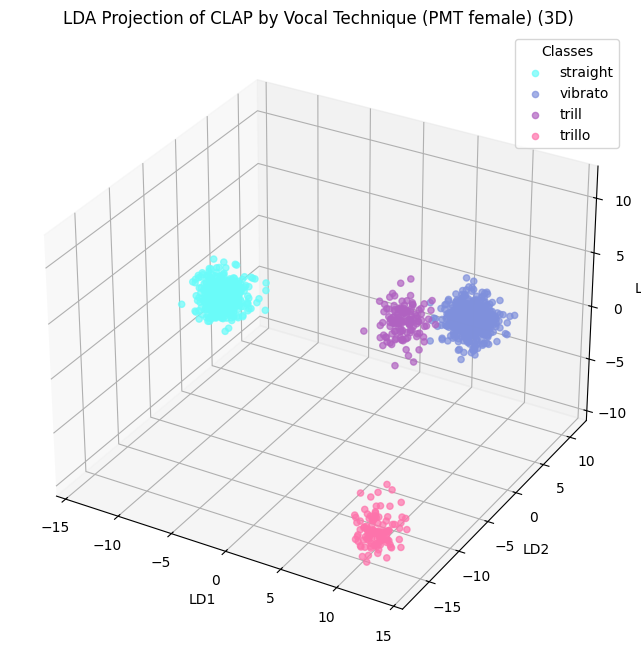

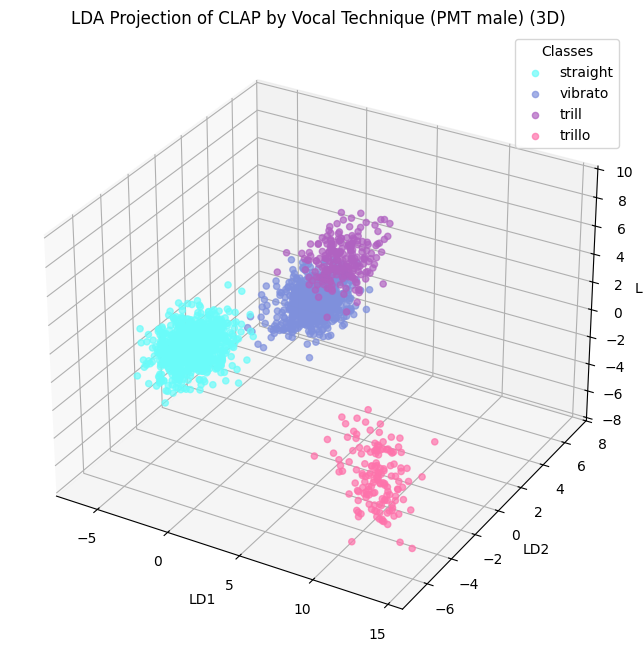

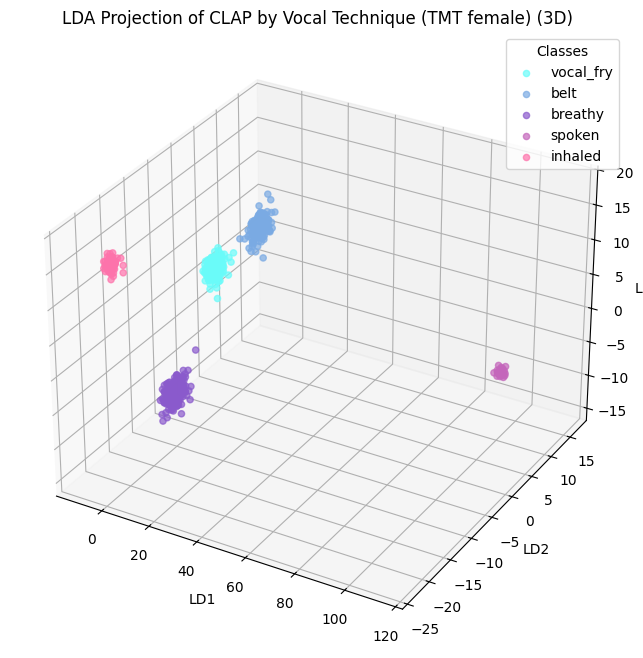

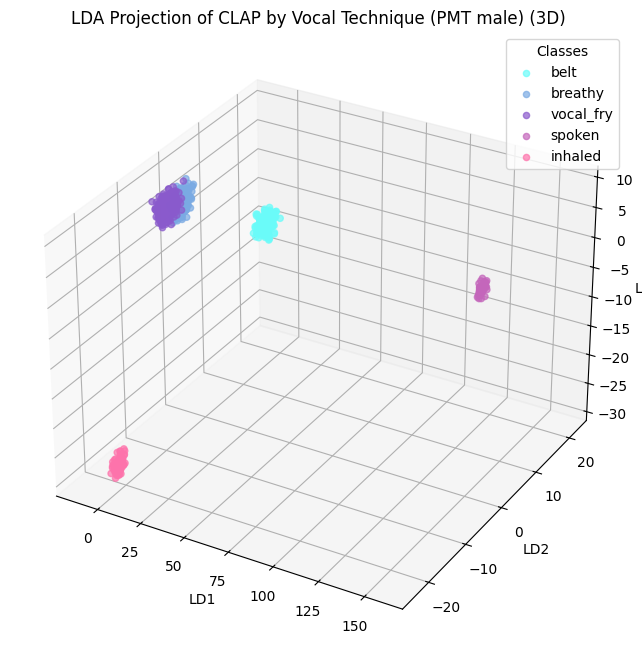

In [75]:
# female only
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (10-way female)",
    filters={"vocal_technique": vocalset_10way, "singer": female_singers},
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (10-way male)",
    filters={"vocal_technique": vocalset_10way, "singer": male_singers},
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (PMT female)",
    filters={
        "vocal_technique": pmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": pmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (TMT female)",
    filters={
        "vocal_technique": tmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_clap,
    class_col="vocal_technique",
    mode="3d",
    data_type="CLAP by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": tmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

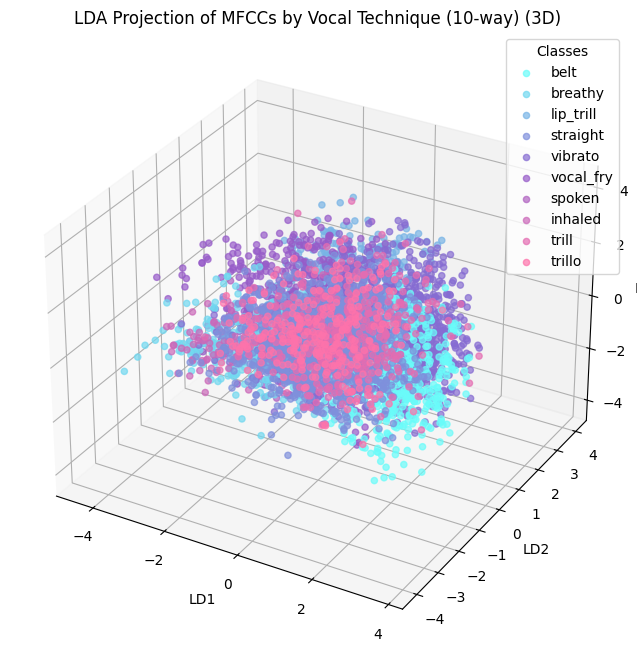

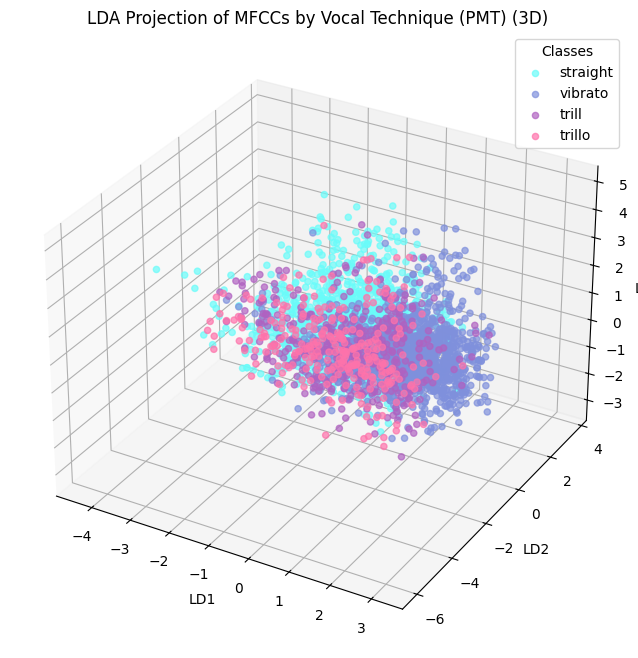

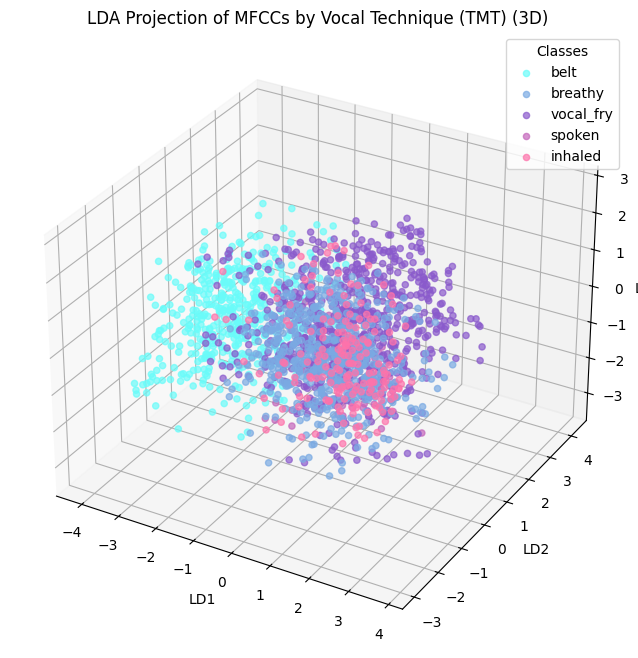

In [76]:
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (10-way)",
    filters={
        "vocal_technique": vocalset_10way
    },
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (PMT)",
    filters={"vocal_technique": pmt},
    palette="musa_palette",
)

prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (TMT)",
    filters={"vocal_technique": tmt},
    palette="musa_palette",
)

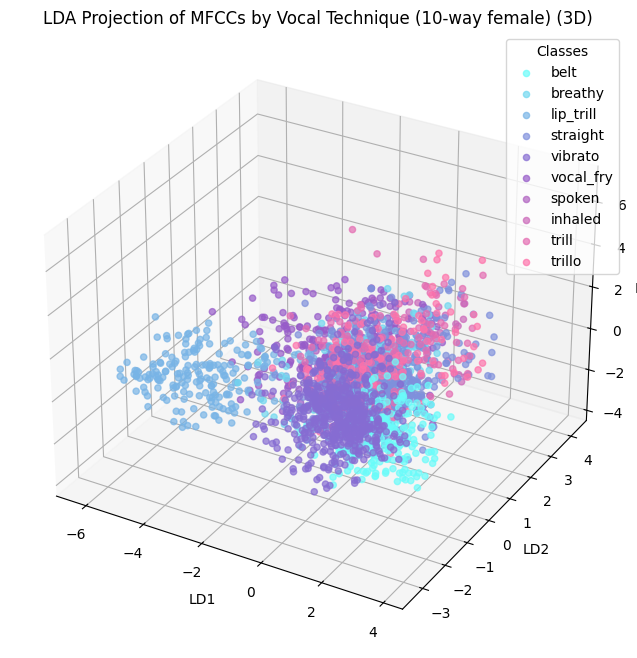

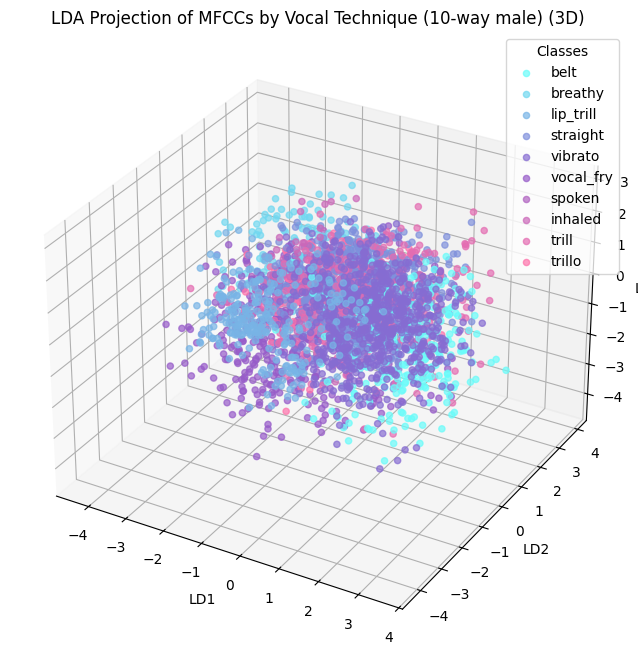

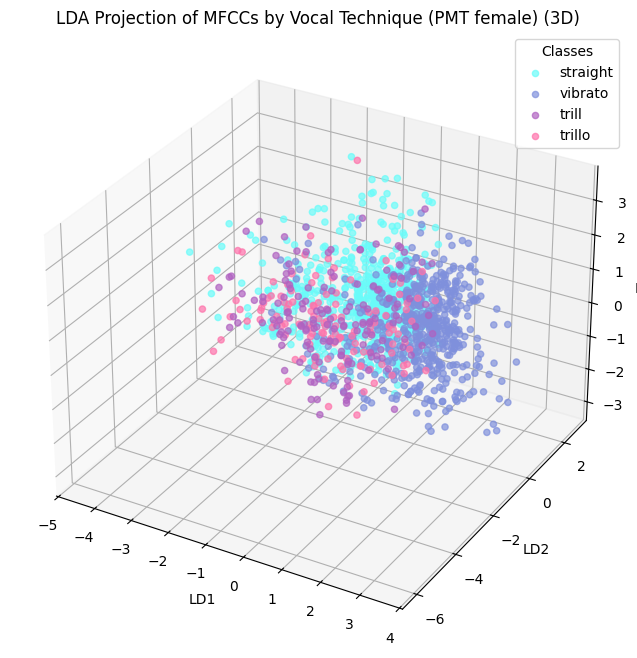

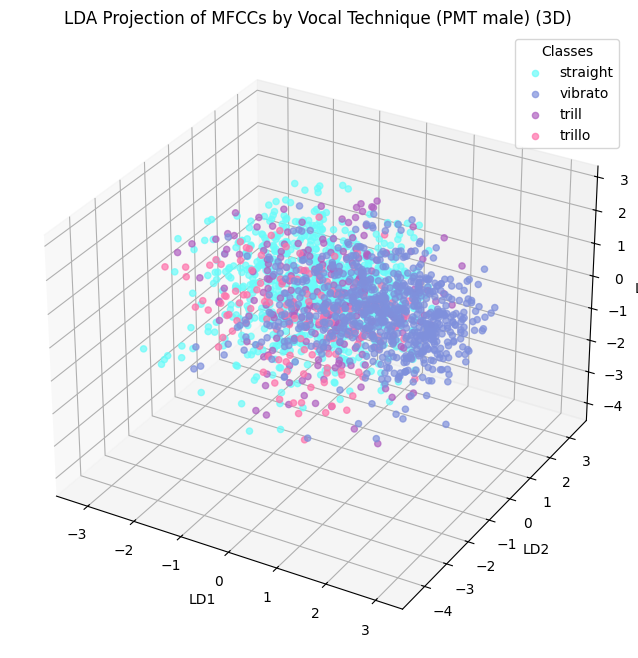

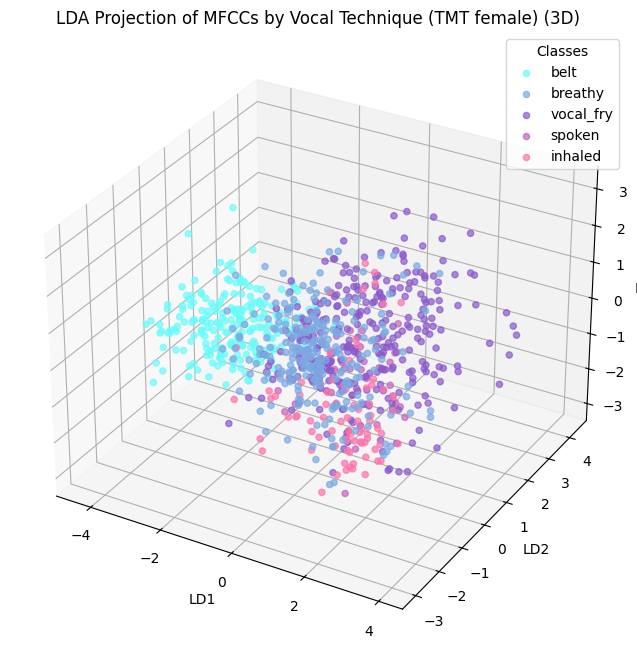

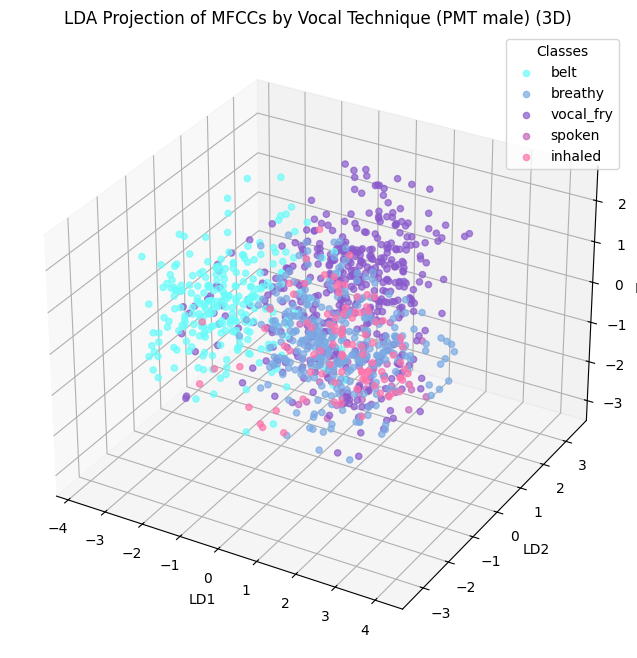

In [77]:
# female only
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (10-way female)",
    filters={"vocal_technique": vocalset_10way, "singer": female_singers},
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (10-way male)",
    filters={"vocal_technique": vocalset_10way, "singer": male_singers},
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (PMT female)",
    filters={
        "vocal_technique": pmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": pmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)

# female only
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (TMT female)",
    filters={
        "vocal_technique": tmt,
        "singer": female_singers,
    },
    palette="musa_palette",
)

# male only
prepare_and_plot_lda(
    df_mfcc,
    class_col="vocal_technique",
    mode="3d",
    data_type="MFCCs by Vocal Technique (PMT male)",
    filters={
        "vocal_technique": tmt,
        "singer": male_singers,
    },
    palette="musa_palette",
)